# 03 — The Statistical Learning Framework
**Goal:** Write the supervised learning problem in the language every
chapter will reuse — model, risk, empirical risk, bias-variance, Bayes
predictor. Source: ISLR Ch2, Shalev-Shwartz & Ben-David Ch2-3.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
np.random.seed(1)

## 1. The setup

We assume the data is drawn i.i.d. from an unknown joint distribution

    (x, y) ~ P(X, Y)

The goal is to learn a function f : 𝒳 → 𝒴 that predicts y from x well.

**Three things to specify:**

1. **Loss function** ℓ : 𝒴 × 𝒴 → ℝ₊ — how wrong one prediction is.
   - Squared:  ℓ(y, ŷ) = (y - ŷ)²
   - Absolute: ℓ(y, ŷ) = |y - ŷ|
   - 0-1:      ℓ(y, ŷ) = 𝟙[y ≠ ŷ]

2. **Model class** ℱ — the set of candidate functions.
   - Linear, polynomial, tree, kernel, neural net, ...

3. **Training algorithm** — how to pick f ∈ ℱ from data.
   - Empirical risk minimization (ERM), regularized ERM, MLE, MAP, ...

## 2. Risk, empirical risk, and the Bayes predictor

**Risk** (expected loss over the data distribution):

    R(f) = 𝔼_{(X,Y) ~ P} [ ℓ(Y, f(X)) ]

**Empirical risk** (loss on the training sample):

    R̂(f) = (1/n) Σᵢ ℓ(yᵢ, f(xᵢ))

The fundamental theorem of statistical learning says R̂ → R as n → ∞
(under regularity). The *speed* of convergence is what distinguishes
parametric models from nonparametric ones.

**Bayes predictor** — the function that minimizes risk pointwise:

    f*(x) = argmin_ŷ 𝔼[ℓ(Y, ŷ) | X = x]

For squared loss:  f*(x) = 𝔼[Y | X = x]  (the regression function).
For 0-1 loss:      f*(x) = argmax_y P(Y = y | X = x)  (the mode).

The Bayes risk R* = R(f*) is *irreducible* — it is the noise floor.

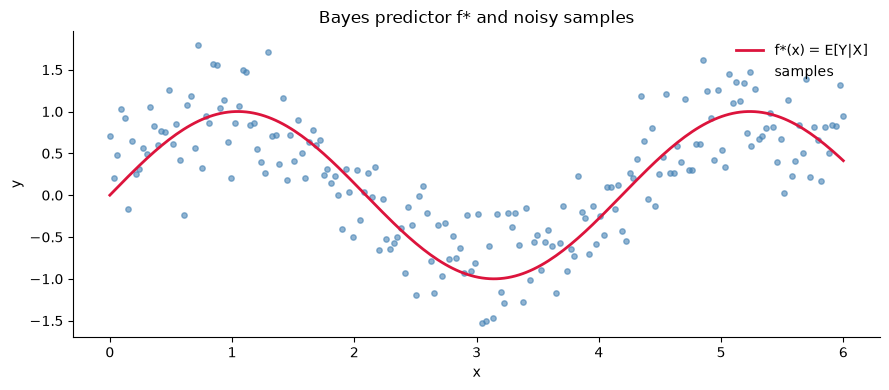

In [2]:
np.random.seed(0)
n = 200
x = np.linspace(0, 6, n)
f_star = np.sin(1.5 * x)                     # the regression function
y = f_star + np.random.normal(0, 0.4, n)     # additive Gaussian noise

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, f_star, color='crimson', lw=2, label='f*(x) = E[Y|X]')
ax.scatter(x, y, s=15, alpha=0.6, color='steelblue', label='samples')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Bayes predictor f* and noisy samples')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Bias-variance decomposition

For squared loss and a fixed x, the expected prediction error of a learned f̂
averaged over training sets is

    𝔼_train[(y - f̂(x))²]  =  bias²(x) + variance(x) + irreducible noise

with
    bias(x)   = f*(x) - 𝔼_train[f̂(x)]
    variance(x) = 𝔼_train[(f̂(x) - 𝔼_train[f̂(x)])²]

The **bias-variance tradeoff** is the single most important concept in
model selection.

- **High bias** = the model class cannot represent the truth (underfit).
- **High variance** = the model class is too sensitive to the training sample (overfit).

Increasing model complexity *decreases* bias but *increases* variance. The
sweet spot is where total error is minimized.

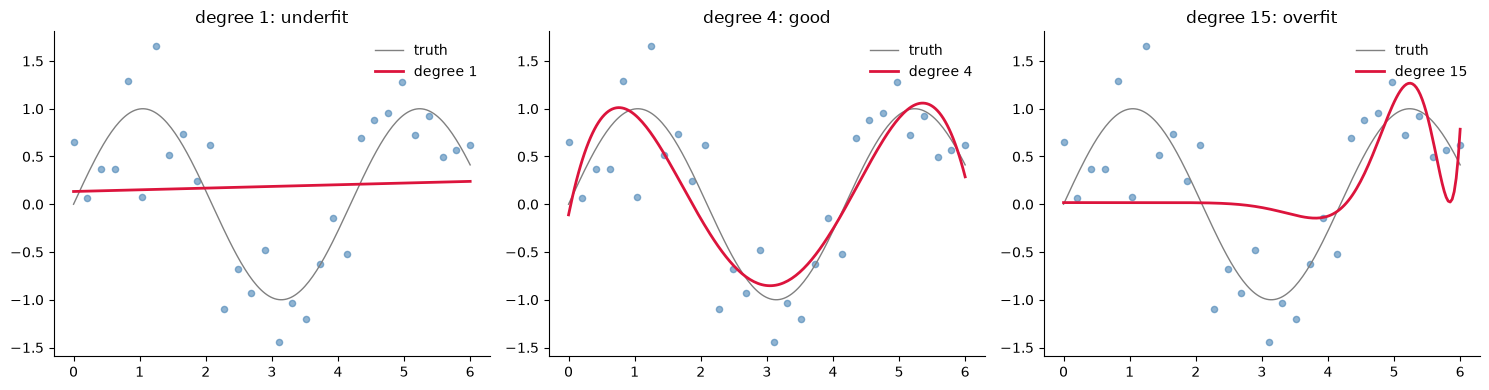

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
np.random.seed(1)
n = 30
x = np.linspace(0, 6, n)
y = np.sin(1.5 * x) + np.random.normal(0, 0.4, n)
x_grid = np.linspace(0, 6, 200)
f_true = np.sin(1.5 * x_grid)
for ax, d in zip(axes, [1, 4, 15]):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x.reshape(-1, 1), y)
    pred = model.predict(x_grid.reshape(-1, 1))
    ax.scatter(x, y, s=20, alpha=0.6, color='steelblue')
    ax.plot(x_grid, f_true, color='gray', lw=1, label='truth')
    ax.plot(x_grid, pred,  color='crimson', lw=2, label=f'degree {d}')
    ax.set_title(f'degree {d}: ' + ('underfit' if d == 1 else ('good' if d == 4 else 'overfit')))
    ax.legend(frameon=False, loc='upper right')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. The variance story — many fits on many samples

The single fit above does not show variance. To see it, draw many training
sets, fit each, and overlay.

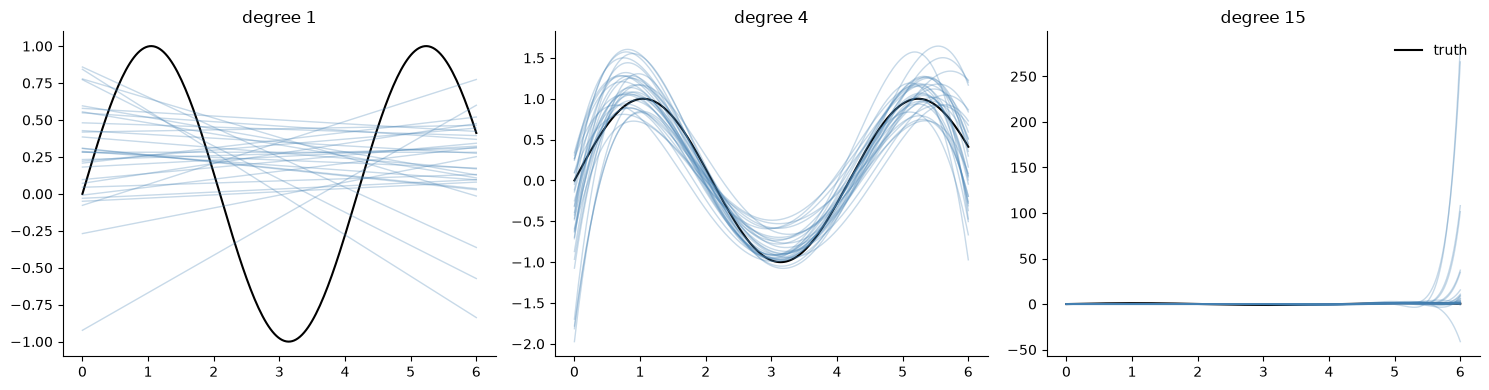

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_grid = np.linspace(0, 6, 200)
f_true = np.sin(1.5 * x_grid)
n, n_datasets = 25, 30
for ax, d in zip(axes, [1, 4, 15]):
    ax.plot(x_grid, f_true, color='black', lw=1.5, label='truth')
    for _ in range(n_datasets):
        x = np.random.uniform(0, 6, n)
        y = np.sin(1.5 * x) + np.random.normal(0, 0.4, n)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression())
        m.fit(x.reshape(-1, 1), y)
        ax.plot(x_grid, m.predict(x_grid.reshape(-1, 1)), color='steelblue', alpha=0.3, lw=1)
    ax.set_title(f'degree {d}')
    ax.spines[['top','right']].set_visible(False)
    if d == 15:
        ax.legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()

## 5. The error vs complexity curve

As model complexity grows, training error can only fall, but test error has
a U-shape. The minimum of test error is the optimal complexity.

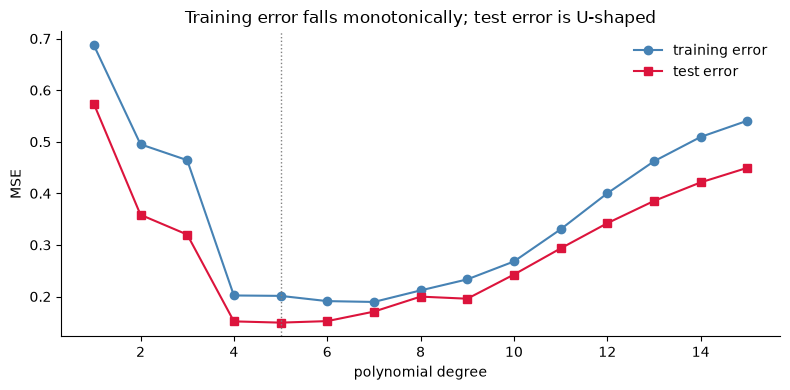

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
np.random.seed(2)
n_total = 200
x = np.random.uniform(0, 6, n_total)
y = np.sin(1.5 * x) + np.random.normal(0, 0.4, n_total)
X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
degrees = list(range(1, 16))
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)))
    te_err.append(mean_squared_error(y_test,  m.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, tr_err, marker='o', color='steelblue', label='training error')
ax.plot(degrees, te_err, marker='s', color='crimson',  label='test error')
ax.axvline(degrees[int(np.argmin(te_err))], color='gray', linestyle=':', lw=1)
ax.set_xlabel('polynomial degree'); ax.set_ylabel('MSE')
ax.set_title('Training error falls monotonically; test error is U-shaped')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. ERM and its limits

**Empirical risk minimization (ERM):**
    f̂ = argmin_{f ∈ ℱ} R̂(f) = argmin_f (1/n) Σᵢ ℓ(yᵢ, f(xᵢ))

ERM is consistent (the solution converges to the best in ℱ) under
mild conditions. But ERM **overfits** when ℱ is rich relative to n. The
fixes are:

1. **Restrict ℱ** — linear models only (notebook 05).
2. **Add a regularizer** — penalize ‖θ‖² (notebook 08).
3. **Average over models** — bagging, boosting (notebook 09).
4. **Get more data** — the universal fix.

## 7. Estimation vs approximation error

Let fℱ* be the best function in ℱ. The expected risk of f̂ decomposes as

    R(f̂)  =  R(fℱ*)                  (approximation error — model class limit)
           + (R(f̂) - R(fℱ*))         (estimation error — finite sample)

Rich ℱ → small approximation, large estimation.
Simple ℱ → large approximation, small estimation.

The whole point of regularization is to *reduce estimation error by accepting
a small approximation error*.

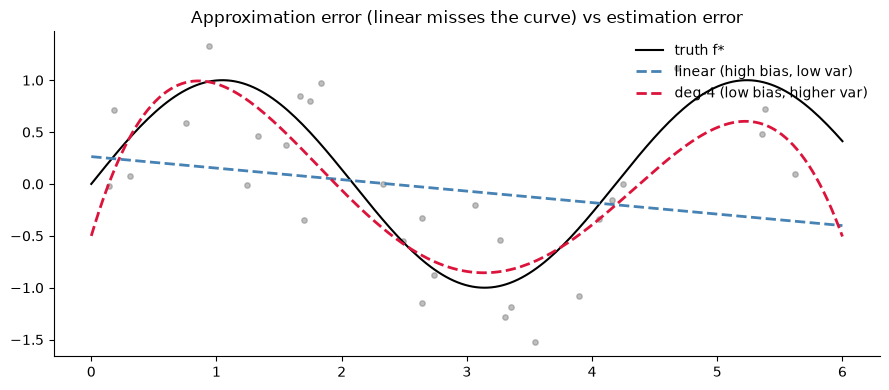

In [6]:
# Conceptual: two model classes fit a sinusoidal truth
fig, ax = plt.subplots(figsize=(9, 4))
x_grid = np.linspace(0, 6, 200)
f_true = np.sin(1.5 * x_grid)
ax.plot(x_grid, f_true, color='black', lw=1.5, label='truth f*')
np.random.seed(3)
x = np.random.uniform(0, 6, 30); y = np.sin(1.5 * x) + np.random.normal(0, 0.4, 30)
m1 = make_pipeline(PolynomialFeatures(1), LinearRegression()).fit(x.reshape(-1, 1), y)
m2 = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(x.reshape(-1, 1), y)
ax.plot(x_grid, m1.predict(x_grid.reshape(-1, 1)), '--', color='steelblue', lw=2, label='linear (high bias, low var)')
ax.plot(x_grid, m2.predict(x_grid.reshape(-1, 1)), '--', color='crimson',  lw=2, label='deg-4 (low bias, higher var)')
ax.scatter(x, y, s=15, alpha=0.5, color='gray')
ax.legend(frameon=False, loc='upper right')
ax.set_title('Approximation error (linear misses the curve) vs estimation error')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Three regimes of data

| Regime | What dominates | What to do |
|---|---|---|
| **Small n, large d** | estimation error | restrict ℱ, regularize heavily |
| **Large n, large d** | approximation error | use rich models (deep nets, RF) |
| **n ≫ d** | noise | focus on data quality, not algorithm |

A useful rule of thumb: with n/d < 10 you are in the first regime; with
n/d > 100 you are in the second; in between, both matter and you should
use cross-validation to choose.

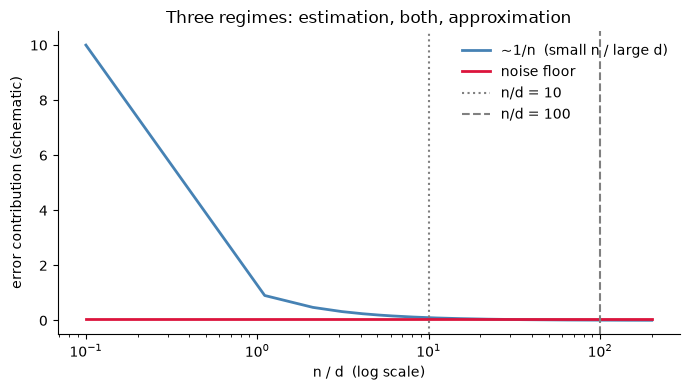

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
nd = np.linspace(0.1, 200, 200)
ax.semilogx(nd, 1/nd, color='steelblue', lw=2, label='~1/n  (small n / large d)')
ax.semilogx(nd, np.ones_like(nd)*0.05, color='crimson', lw=2, label='noise floor')
ax.axvline(10,  color='gray', linestyle=':', label='n/d = 10')
ax.axvline(100, color='gray', linestyle='--', label='n/d = 100')
ax.set_xlabel('n / d  (log scale)')
ax.set_ylabel('error contribution (schematic)')
ax.set_title('Three regimes: estimation, both, approximation')
ax.legend(frameon=False, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Summary

| Concept | Key point |
|---|---|
| Risk vs empirical risk | Population vs sample average loss |
| Bayes predictor f* | Best in expectation; defines the noise floor |
| Bias-variance | 𝔼[(y - f̂)²] = bias² + variance + noise |
| ERM | Minimizes empirical risk; overfits if ℱ is rich |
| Approximation + estimation | The two sources of generalization error |

**Next:** `04_data_preprocessing.ipynb` — turning raw data into something a
model can fit.